In [14]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

# ---- Hyperparameters ----
input_shape = (41, 62)
embedding_dim = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset_path = "modified_self_dataset"
model_path = "siamese_model.pth"

# ---- Siamese Model ----
import torch.nn as nn

class SiameseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(62, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, embedding_dim)
        )

    def forward_once(self, x):
        x = x.unsqueeze(0).permute(0, 2, 1)  # (1, 62, 41)
        return self.encoder(x)  # (1, 128)

# ---- Load Model ----
model = SiameseNet().to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

# ---- Compute Class Means ----
class_means = {}
for class_name in tqdm(os.listdir(dataset_path)):
    class_folder = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_folder):
        continue

    embeddings = []
    for file in os.listdir(class_folder):
        if file.endswith('.csv'):
            csv_path = os.path.join(class_folder, file)
            data = pd.read_csv(csv_path, header=None).values.astype(np.float32)
            if data.shape != input_shape:
                continue  # skip files with wrong shape
            data_tensor = torch.tensor(data).to(device)
            with torch.no_grad():
                embedding = model.forward_once(data_tensor).squeeze().cpu().numpy()
                embeddings.append(embedding)

    if embeddings:
        class_mean = np.mean(embeddings, axis=0)
        class_means[class_name] = class_mean
        print(f"Class {class_name} mean vector shape: {class_mean.shape}")

import json

# Convert numpy arrays to lists for JSON compatibility
class_means_serializable = {
    class_name: mean.tolist()
    for class_name, mean in class_means.items()
}

# Save to JSON
with open("class_means.json", "w") as f:
    json.dump(class_means_serializable, f, indent=2)

print("Saved class means to class_means.json")





  4%|▍         | 1/23 [00:00<00:04,  4.51it/s]

Class drumming_fingers mean vector shape: (128,)


  9%|▊         | 2/23 [00:00<00:05,  4.20it/s]

Class pulling_hand_in mean vector shape: (128,)
Class pulling_two_fingers_in mean vector shape: (128,)


 17%|█▋        | 4/23 [00:00<00:04,  4.65it/s]

...

Class zooming_in_with_two_fingers mean vector shape: (128,)


 96%|█████████▌| 22/23 [00:04<00:00,  4.65it/s]

Class zooming_out_with_two_fingers mean vector shape: (128,)


100%|██████████| 23/23 [00:04<00:00,  4.69it/s]

Class zoom_out_with_full_hand mean vector shape: (128,)
Saved class means to class_means.json


Generating embeddings from dataset...
Collected 461 embeddings.
Applying t-SNE...
Plotting...


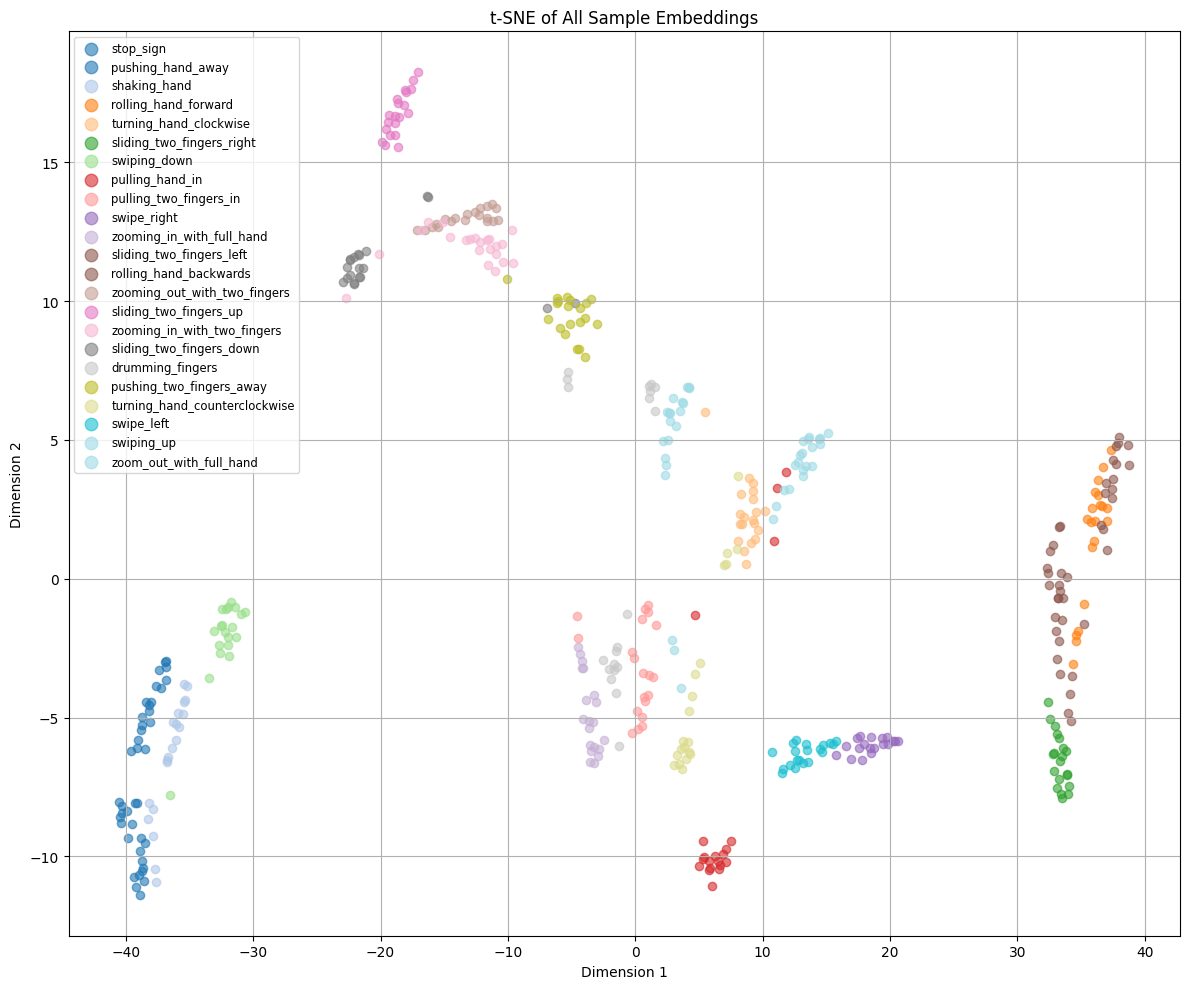

In [15]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import defaultdict

# ---- Load Model ----
class SiameseNet(torch.nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv1d(62, 128, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv1d(128, 128, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
            torch.nn.Flatten(),
            torch.nn.Linear(128, embedding_dim)
        )

    def forward_once(self, x):
        # x: (B, 1, 41, 62)
        x = x.squeeze(1).permute(0, 2, 1)  # (B, 62, 41)
        return self.encoder(x)

    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)

# Load trained model
model = SiameseNet()
model.load_state_dict(torch.load("siamese_model.pth", map_location="cpu"))
model.eval()

# ---- Collect Embeddings ----
dataset_folder = "modified_self_dataset"
embeddings = []
labels = []

print("Generating embeddings from dataset...")

with torch.no_grad():
    for class_name in os.listdir(dataset_folder):
        class_path = os.path.join(dataset_folder, class_name)
        if not os.path.isdir(class_path): continue

        for filename in os.listdir(class_path):
            if not filename.endswith(".csv"): continue
            csv_path = os.path.join(class_path, filename)

            try:
                array = pd.read_csv(csv_path, header=None).values.astype(np.float32)
                if array.shape != (41, 62): continue  # skip invalid shapes
                tensor = torch.tensor(array).unsqueeze(0).unsqueeze(0)  # (1, 1, 41, 62)
                embedding = model.forward_once(tensor).squeeze(0).numpy()
                embeddings.append(embedding)
                labels.append(class_name)
            except Exception as e:
                print(f"Skipping {csv_path} due to error: {e}")

embeddings = np.array(embeddings)
print(f"Collected {len(embeddings)} embeddings.")

# ---- Apply t-SNE ----
print("Applying t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

# ---- Plot ----
print("Plotting...")
plt.figure(figsize=(12, 10))
unique_labels = list(set(labels))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    idxs = [j for j, lbl in enumerate(labels) if lbl == label]
    points = embeddings_2d[idxs]
    plt.scatter(points[:, 0], points[:, 1], label=label, alpha=0.6, color=colors[i])

plt.title("t-SNE of All Sample Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(loc="best", fontsize='small', markerscale=1.5)
plt.grid(True)
plt.tight_layout()
plt.show()

